# Synthetic E-commerce SQL Benchmark

Ноутбук описывает локальный synthetic benchmark для проверки SQL-набора: схему, данные, edge-case слой, execution-статистику и coverage.

## 1. Загрузка артефактов

Здесь загружаются source-артефакты synthetic benchmark и итоговый coverage-отчет, рассчитанный на заполненной `SQLite`-базе.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style='whitegrid', context='talk')
pd.options.display.float_format = '{:.4f}'.format

NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = next(
    candidate
    for candidate in (NOTEBOOK_DIR, *NOTEBOOK_DIR.parents)
    if (candidate / 'nl2sql').exists() and (candidate / 'shared').exists()
)

DATA_DIR = PROJECT_ROOT / 'data' / 'nl2sql' / 'synthetic_ecommerce'
DATASET_PATH = DATA_DIR / 'dataset_v1.json'
EDGE_PATH = DATA_DIR / 'edge_cases_v1.json'
COVERAGE_PATH = DATA_DIR / 'coverage_summary.json'
DB_PATH = DATA_DIR / 'snapshot.sqlite'

with DATASET_PATH.open('r', encoding='utf-8') as handle:
    dataset = json.load(handle)
with EDGE_PATH.open('r', encoding='utf-8') as handle:
    edge_cases = json.load(handle)
with COVERAGE_PATH.open('r', encoding='utf-8') as handle:
    coverage = json.load(handle)

core_queries_df = pd.DataFrame(dataset['queries'])
edge_queries_df = pd.DataFrame(edge_cases['queries'])
query_results_df = pd.DataFrame(coverage['query_results'])
row_counts_df = pd.DataFrame([
    {'table': key, 'rows': value} for key, value in coverage['row_counts'].items()
])
column_usage_df = pd.DataFrame([
    {'column': key, 'usage_count': value} for key, value in coverage['column_usage'].items()
]).sort_values(['usage_count', 'column'], ascending=[False, True])
null_ratio_df = pd.DataFrame([
    {'column': key, 'null_ratio': value}
    for key, value in coverage['data_quality_summary']['null_ratio_by_column'].items()
]).sort_values(['null_ratio', 'column'], ascending=[False, True])


## 2. Состав набора

Synthetic benchmark состоит из базового ядра `30` SQL-запросов и отдельного supplemental edge-case слоя. Ядро сохраняет распределение `10 / 10 / 10`, а edge-cases не смешиваются с ним.

In [2]:
summary_df = pd.DataFrame(
    [
        {'metric': 'Core queries', 'value': coverage['query_counts']['core']},
        {'metric': 'Edge-case queries', 'value': coverage['query_counts']['edge_case']},
        {'metric': 'Total queries', 'value': coverage['query_counts']['total']},
        {'metric': 'SQLite snapshot', 'value': DB_PATH.name},
    ]
)

edge_queries_display_df = edge_queries_df[['difficulty', 'group', 'edge_type']].fillna({'edge_type': '—'})

display(summary_df)
display(core_queries_df['difficulty'].value_counts().rename_axis('difficulty').reset_index(name='count'))
display(edge_queries_display_df)


,metric,value
0,Core queries,30
1,Edge-case queries,8
2,Total queries,38
3,SQLite snapshot,snapshot.sqlite


,difficulty,count
0,easy,10
1,medium,10
2,hard,10


,difficulty,group,edge_type
0,edge_case,edge_case,anti_join
1,edge_case,edge_case,anti_join
2,edge_case,edge_case,null_handling
3,edge_case,edge_case,empty_result
4,edge_case,edge_case,null_handling
5,edge_case,edge_case,aggregation_edge
6,edge_case,edge_case,aggregation_edge
7,edge_case,edge_case,empty_result


## 3. Данные и качество заполнения

В этом разделе фиксируются размеры таблиц и краткая характеристика “грязи” в synthetic data: доли `NULL` и несколько контролируемых нестандартных значений.

In [3]:
display(row_counts_df)
display(null_ratio_df.head(12))
display(pd.DataFrame([
    {'check': key, 'count': value}
    for key, value in coverage['data_quality_summary']['unusual_value_checks'].items()
]))


,table,rows
0,customers,420
1,categories,24
2,products,220
3,orders,720
4,order_items,1440
5,returns,180


,column,null_ratio
23,orders.shipping_state,0.3333
2,categories.parent_category_id,0.2500
36,returns.return_reason,0.1222
10,customers.state,0.1095
28,products.launched_at,0.0682
11,order_items.discount_amount,0.0382
3,customers.city,0.0262
0,categories.category_id,0.0000
1,categories.category_name,0.0000
4,customers.customer_id,0.0000


,check,count
0,products.brand:Brand-X/Legacy,7
1,orders.payment_method:crypto,36
2,returns.return_reason:empty_string,14


## 4. Execution Statistics

Ниже показаны результаты реального исполнения SQL на заполненной базе: число возвращаемых строк и время выполнения каждого запроса.

,zero_rows_queries,one_row_queries,multi_row_queries,zero_or_one_ratio,is_skewed_to_zero_or_one
0,1,1,36,0.0526,False


,index,group,difficulty,edge_type,rows_returned,execution_time_ms,selectivity
0,1,core,easy,—,46,1.2293,selective
1,2,core,easy,—,5,0.3370,selective
2,3,core,easy,—,36,0.1798,selective
3,4,core,easy,—,42,0.4145,selective
4,5,core,easy,—,10,0.2398,selective
5,6,core,easy,—,6,0.1430,selective
6,7,core,easy,—,47,0.1641,selective
7,8,core,easy,—,10,0.2402,selective
8,9,core,easy,—,379,0.7297,selective
9,10,core,easy,—,30,0.0975,selective


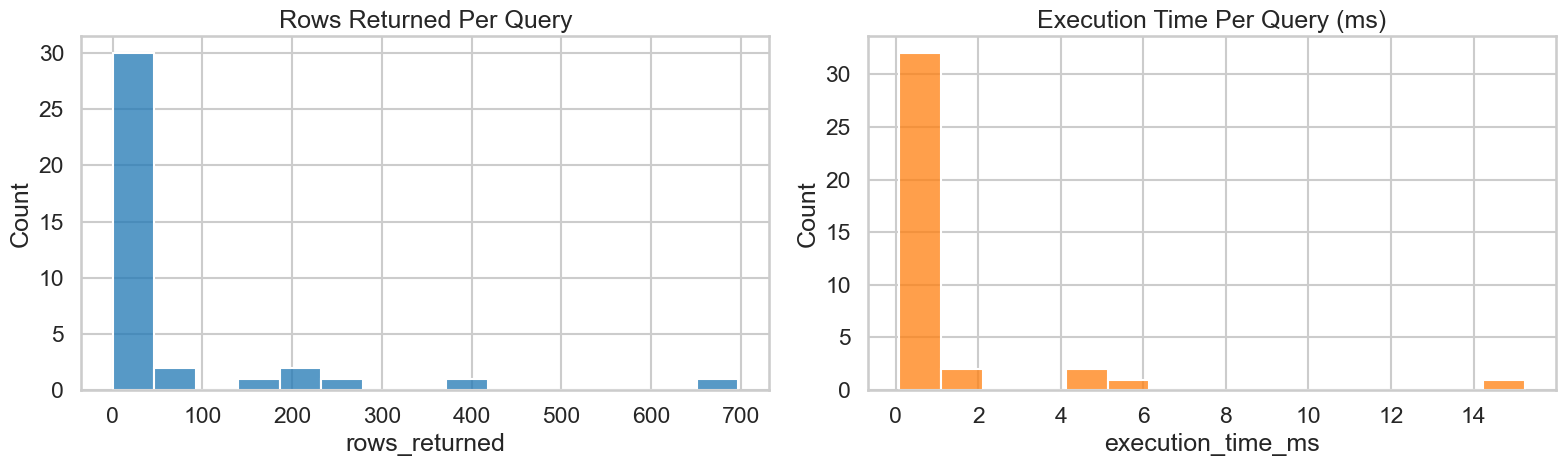

In [4]:
result_distribution_df = pd.DataFrame([coverage['result_distribution']])
query_results_preview_df = query_results_df[['index', 'group', 'difficulty', 'edge_type', 'rows_returned', 'execution_time_ms', 'selectivity']].copy()
query_results_preview_df['edge_type'] = query_results_preview_df['edge_type'].fillna('—')
display(result_distribution_df)
display(query_results_preview_df.head(15))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(query_results_df['rows_returned'], bins=15, ax=axes[0], color='#1f77b4')
axes[0].set_title('Rows Returned Per Query')
axes[0].set_xlabel('rows_returned')

sns.histplot(query_results_df['execution_time_ms'], bins=15, ax=axes[1], color='#ff7f0e')
axes[1].set_title('Execution Time Per Query (ms)')
axes[1].set_xlabel('execution_time_ms')
plt.tight_layout()


## 5. Coverage и распределения

Этот блок показывает, насколько равномерно используются таблицы и колонки, а также как распределяются аналитические intent’ы, селективность и edge-case типы.

,edge_type,count
0,aggregation_edge,2
1,anti_join,2
2,empty_result,2
3,null_handling,2


,unused_columns


,low_usage_columns
0,categories.parent_category_id
1,customers.city
2,orders.order_date
3,products.is_active
4,products.launched_at
5,returns.return_date


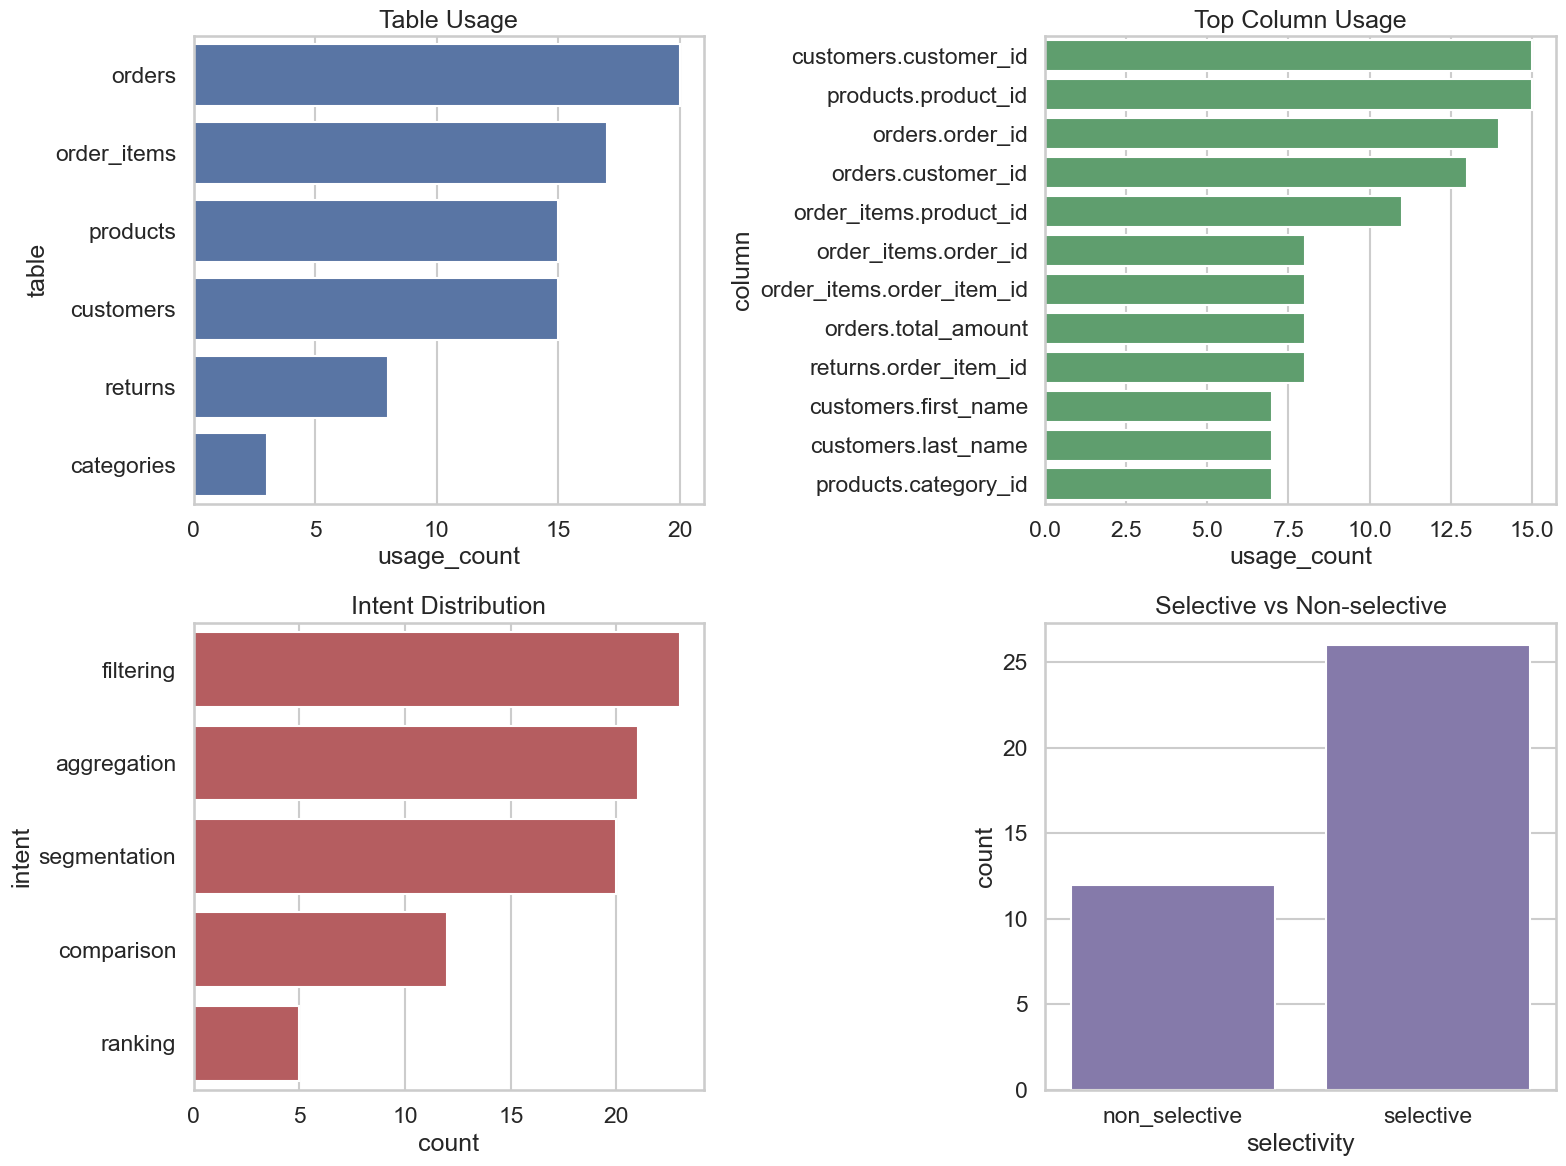

In [5]:
table_usage_df = pd.DataFrame([
    {'table': key, 'usage_count': value}
    for key, value in coverage['table_usage'].items()
]).sort_values('usage_count', ascending=False)
intent_df = pd.DataFrame([
    {'intent': key, 'count': value}
    for key, value in coverage['intent_distribution'].items()
]).sort_values('count', ascending=False)
selectivity_df = pd.DataFrame([
    {'selectivity': key, 'count': value}
    for key, value in coverage['selectivity_distribution'].items()
])
edge_type_df = pd.DataFrame([
    {'edge_type': key, 'count': value}
    for key, value in coverage['edge_type_distribution'].items()
]).sort_values('count', ascending=False)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
sns.barplot(data=table_usage_df, x='usage_count', y='table', ax=axes[0, 0], color='#4c72b0')
axes[0, 0].set_title('Table Usage')

sns.barplot(data=column_usage_df.head(12), x='usage_count', y='column', ax=axes[0, 1], color='#55a868')
axes[0, 1].set_title('Top Column Usage')

sns.barplot(data=intent_df, x='count', y='intent', ax=axes[1, 0], color='#c44e52')
axes[1, 0].set_title('Intent Distribution')

sns.barplot(data=selectivity_df, x='selectivity', y='count', ax=axes[1, 1], color='#8172b2')
axes[1, 1].set_title('Selective vs Non-selective')
plt.tight_layout()

display(edge_type_df)
display(pd.DataFrame({'unused_columns': coverage['unused_columns']}))
display(pd.DataFrame({'low_usage_columns': coverage['low_usage_columns']}))


## 6. Краткие выводы

Synthetic benchmark уже пригоден для executable проверки: все запросы исполняются на заполненной `SQLite`-базе, перекоса в `0/1` по числу строк нет, все таблицы и все колонки из схемы используются хотя бы один раз. При этом coverage-отчет сохраняет список колонок с низкой частотой использования, что удобно для следующей итерации набора.